# Indian Recipe Recommender — How It Works

This notebook walks through every step of the recommendation system, from raw CSV to ranked results.

**Pipeline overview:**
```
Raw CSV  →  Clean & combine text  →  Sentence embeddings  →  Cosine similarity  →  Ranked results
```

## Step 1 — Load & Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dataset/IndianFoodDatasetCSV.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (6871, 15)


,Srno,RecipeName,TranslatedRecipeName,Ingredients,TranslatedIngredients,PrepTimeInMins,CookTimeInMins,TotalTimeInMins,Servings,Cuisine,Course,Diet,Instructions,TranslatedInstructions,URL
0,1,Masala Karela Recipe,Masala Karela Recipe,"6 Karela (Bitter Gourd/ Pavakkai) - deseeded,S...","6 Karela (Bitter Gourd/ Pavakkai) - deseeded,S...",15,30,45,6,Indian,Side Dish,Diabetic Friendly,"To begin making the Masala Karela Recipe,de-se...","To begin making the Masala Karela Recipe,de-se...",https://www.archanaskitchen.com/masala-karela-...
1,2,टमाटर पुलियोगरे रेसिपी - Spicy Tomato Rice (Re...,Spicy Tomato Rice (Recipe),"2-1/2 कप चावल - पका ले,3 टमाटर,3 छोटा चमच्च बी...","2-1 / 2 cups rice - cooked, 3 tomatoes, 3 teas...",5,10,15,3,South Indian Recipes,Main Course,Vegetarian,टमाटर पुलियोगरे बनाने के लिए सबसे पहले टमाटर क...,"To make tomato puliogere, first cut the tomato...",http://www.archanaskitchen.com/spicy-tomato-ri...
2,3,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,"1-1/2 cups Rice Vermicelli Noodles (Thin),1 On...","1-1/2 cups Rice Vermicelli Noodles (Thin),1 On...",20,30,50,4,South Indian Recipes,South Indian Breakfast,High Protein Vegetarian,"To begin making the Ragi Vermicelli Recipe, fi...","To begin making the Ragi Vermicelli Recipe, fi...",http://www.archanaskitchen.com/ragi-vermicelli...


In [2]:
# Columns we care about
print(df[['TranslatedRecipeName','TranslatedIngredients','Cuisine','Diet','Course','TotalTimeInMins']].dtypes)
print('\nNull counts:')
print(df[['TranslatedRecipeName','TranslatedIngredients','Cuisine','Diet','Course']].isnull().sum())

TranslatedRecipeName       str
TranslatedIngredients      str
Cuisine                    str
Diet                       str
Course                     str
TotalTimeInMins          int64
dtype: object

Null counts:
TranslatedRecipeName     0
TranslatedIngredients    6
Cuisine                  0
Diet                     0
Course                   0
dtype: int64


## Step 2 — Clean & Build `combined_text`

Each recipe is represented as a single string that combines its name, ingredients, cuisine, diet and course.
This is the text the model will embed into a vector.

In [3]:
df = df.dropna(subset=['RecipeName', 'TranslatedIngredients']).reset_index(drop=True)
df['TranslatedIngredients'] = df['TranslatedIngredients'].fillna('')
df['Cuisine'] = df['Cuisine'].fillna('Unknown')
df['Diet']    = df['Diet'].fillna('Unknown')
df['Course']  = df['Course'].fillna('Unknown')

df['combined_text'] = (
    df['TranslatedRecipeName'].fillna('') + ' '
    + df['TranslatedIngredients'] + ' '
    + df['Cuisine'] + ' '
    + df['Diet'] + ' '
    + df['Course']
)

print(f'Recipes after cleaning: {len(df)}')
print('\nExample combined_text:')
print(df['combined_text'].iloc[0][:300])

Recipes after cleaning: 6865

Example combined_text:
Masala Karela Recipe 6 Karela (Bitter Gourd/ Pavakkai) - deseeded,Salt - to taste,1 Onion - thinly sliced,3 tablespoon Gram flour (besan),2 teaspoons Turmeric powder (Haldi),1 tablespoon Red Chilli powder,2 teaspoons Cumin seeds (Jeera),1 tablespoon Coriander Powder (Dhania),1 tablespoon Amchur (Dry


## Step 3 — Sentence Embeddings

`all-MiniLM-L6-v2` converts each `combined_text` string into a **384-dimensional vector**.
Texts with similar meaning end up close together in this 384-D space.

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Embed first 5 recipes as a quick demo
sample_texts = df['combined_text'].tolist()[:5]
sample_embs  = model.encode(sample_texts)

print(f'Embedding shape for 5 recipes: {sample_embs.shape}')  # (5, 384)
print(f'Each recipe → vector of {sample_embs.shape[1]} floats')

/home/achyutananda-sahoo/Desktop/SMAI-A3/Assignment-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1349.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape for 5 recipes: (5, 384)
Each recipe → vector of 384 floats


In [5]:
# Embed ALL recipes (takes ~20-30 seconds)
print('Embedding all recipes...')
embeddings = model.encode(df['combined_text'].tolist(), show_progress_bar=True, batch_size=64)
print(f'\nFinal embeddings shape: {embeddings.shape}')  # (N_recipes, 384)

Embedding all recipes...


Batches: 100%|██████████| 108/108 [00:20<00:00,  5.21it/s]



Final embeddings shape: (6865, 384)


In [7]:
embeddings[0]

array([-8.51697400e-02,  4.49395254e-02, -9.41701531e-02,  3.97401908e-03,
       -6.76502362e-02,  3.94890718e-02, -4.21936773e-02,  3.60698886e-02,
        4.42530203e-04, -4.36141156e-03,  2.58296374e-02, -6.39031874e-03,
       -1.17159650e-01, -7.16338679e-02,  2.41791271e-02, -1.28089786e-02,
        9.88544300e-02,  6.02536350e-02,  1.32151484e-03, -6.59265965e-02,
        4.81836237e-02,  4.58427239e-03,  4.74869311e-02, -6.00282662e-02,
        6.35782257e-02,  3.90684418e-02,  4.20978293e-02,  2.41018627e-02,
        3.16536948e-02, -2.28536874e-02,  5.84964827e-02,  7.98357129e-02,
        1.99110433e-02, -2.27475967e-02,  5.49275614e-03,  8.71977657e-02,
       -1.83909060e-03, -1.29173502e-01,  2.82933991e-02,  2.24973392e-02,
        7.37494901e-02,  7.42826834e-02, -2.23226510e-02, -8.73272046e-02,
        1.41659481e-02, -2.65110806e-02, -9.98242423e-02,  1.96811110e-02,
        4.91206944e-02, -2.17974163e-03, -1.19179919e-01, -4.91264947e-02,
        4.92185238e-04, -

## Step 4 — Cosine Similarity

When a user types a query, we:
1. Embed the query into the same 384-D space
2. Compute cosine similarity between the query vector and every recipe vector
3. Sort by score — higher = more similar

**Cosine similarity** measures the angle between two vectors (not their magnitude),
so it works well for text regardless of length.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

query = 'paneer, tomato, onion, cream'
query_vec = model.encode([query])           # shape: (1, 384)

scores = cosine_similarity(query_vec, embeddings)[0]   # shape: (N_recipes,)

print(f'Query vector shape  : {query_vec.shape}')
print(f'Scores array shape  : {scores.shape}')
print(f'Min score: {scores.min():.3f}  |  Max score: {scores.max():.3f}')

Query vector shape  : (1, 384)
Scores array shape  : (6865,)
Min score: 0.127  |  Max score: 0.765


## Step 5 — Rank & Display Results

In [9]:
TOP_K = 10
top_idx = np.argsort(scores)[::-1][:TOP_K]

results = df.iloc[top_idx][['TranslatedRecipeName','Cuisine','Diet','Course','TotalTimeInMins']].copy()
results['similarity'] = scores[top_idx].round(3)
results.reset_index(drop=True, inplace=True)
results

,TranslatedRecipeName,Cuisine,Diet,Course,TotalTimeInMins,similarity
0,UP Style Paneer In Mustard Gravy Recipe,Uttar Pradesh,Vegetarian,Lunch,30,0.765
1,Paneer Onion Paratha Recipe,North Indian Recipes,High Protein Vegetarian,Lunch,45,0.749
2,Tomatoes Stuffed With Mint Mayo And Paneer Recipe,Continental,Vegetarian,Side Dish,50,0.743
3,Paneer Do Pyaza Recipe,North Indian Recipes,Vegetarian,Dinner,40,0.740
4,Spicy Tandoori Paneer Open Puff Recipe,French,Vegetarian,Snack,155,0.739
5,Paneer in Yogurt Tomato Curry (Recipe In Hindi),Kashmiri,Vegetarian,Lunch,50,0.737
6,Sweet And Sour Vegetables With Paneer Curry Re...,Asian,Vegetarian,Dinner,40,0.731
7,Paneer Matar Keema Recipe,North Indian Recipes,Vegetarian,Lunch,65,0.727
8,Aloo Matar Paneer Curry Recipe,North Indian Recipes,Vegetarian,Lunch,55,0.727
9,Paneer in White Gravy Recipe - No Onion No Gar...,North Indian Recipes,Vegetarian,Lunch,35,0.727


## Step 6 — Filtering by Cuisine / Diet / Course

Before computing similarity we can restrict the search space using boolean masks.

In [10]:
query      = 'chicken, spices, ginger'
cuisine    = 'North Indian Recipes'
max_time   = 60

mask = (df['Cuisine'] == cuisine) & (df['TotalTimeInMins'] <= max_time)
filtered_df   = df[mask].reset_index(drop=True)
filtered_embs = embeddings[np.where(mask)[0]]

query_vec = model.encode([query])
scores    = cosine_similarity(query_vec, filtered_embs)[0]
top_idx   = np.argsort(scores)[::-1][:5]

res = filtered_df.iloc[top_idx][['TranslatedRecipeName','Cuisine','Diet','TotalTimeInMins']].copy()
res['similarity'] = scores[top_idx].round(3)
res.reset_index(drop=True, inplace=True)
res

,TranslatedRecipeName,Cuisine,Diet,TotalTimeInMins,similarity
0,Spicy Minced Chicken Keema Balls Curry Recipe,North Indian Recipes,Non Vegeterian,30,0.640
1,Chicken Jalfrezi Recipe - Chicken And Bell Pep...,North Indian Recipes,High Protein Non Vegetarian,55,0.636
2,Pahadi Chicken Curry Recipe,North Indian Recipes,Non Vegeterian,45,0.630
3,Spicy and Tangy Mixed Vegetable Poha Recipe Wi...,North Indian Recipes,Vegetarian,30,0.623
4,Garlic Red Chicken Gravy Recipe,North Indian Recipes,High Protein Non Vegetarian,20,0.620


## Step 7 — Visualise the Embedding Space (PCA)

Reduce 384-D embeddings to 2-D using PCA to see how recipes cluster.

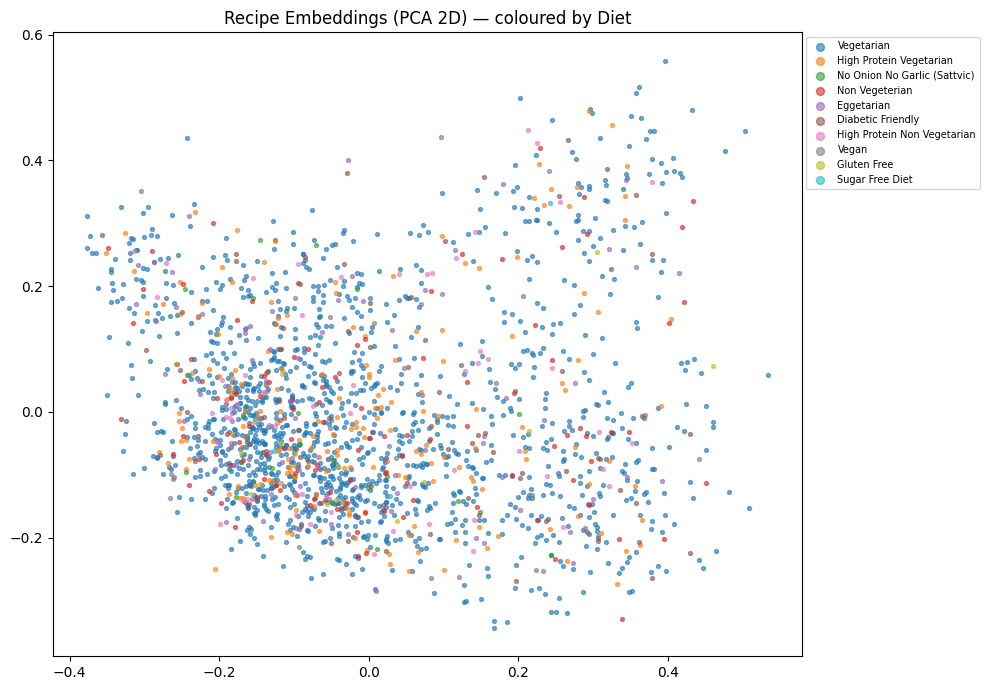

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use a 2000-recipe sample to keep it fast
sample_size = 2000
sample_df   = df.sample(sample_size, random_state=42).reset_index(drop=True)
sample_embs = embeddings[sample_df.index]

pca   = PCA(n_components=2)
coords = pca.fit_transform(sample_embs)

diets = sample_df['Diet'].unique()
color_map = {d: plt.cm.tab20(i / len(diets)) for i, d in enumerate(diets)}

plt.figure(figsize=(10, 7))
for diet in diets:
    idx = sample_df['Diet'] == diet
    plt.scatter(coords[idx, 0], coords[idx, 1], label=diet,
                s=8, alpha=0.6, color=color_map[diet])

plt.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1, 1))
plt.title('Recipe Embeddings (PCA 2D) — coloured by Diet')
plt.tight_layout()
plt.show()